<a href="https://colab.research.google.com/github/Sun2301/TicTacToeRL-RobotArm/blob/feature%2Fdecision-qlearning/decision/Copy_of_Notebook_versionMrAudrey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----
## Apprentissage par renforcement - Q_learning - v3.2
----
The purpose of this new version is to fit the achitecture of the qtable of Johannes meaning that state is represented by a list `[x, x, x, x, x, x, x, x, x]` of length $9$

In [17]:
import random
import numpy as np
from copy import deepcopy
from tqdm import tqdm

In [18]:
# Board structure
# | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |

# This dictiionary provides the possible actions from each postion of the table.
CONSTRAINT_DICT = {
    0: [1, 3, 4],
    1: [0, 2, 4],
    2: [1, 4, 5],
    3: [0, 4, 6],
    4: [0, 1, 2, 3, 5, 6, 7, 8],
    5: [2, 4, 8],
    6: [3, 4, 7],
    7: [4, 6, 8],
    8: [4, 5, 7],
}

In [19]:
def state_to_tuple(state):
    """
    Convert the state into Tuple to let use it as a key of a dictionnary
    """
    return tuple(state)

In [20]:
def available_action(state = np.zeros((9,)), is_current_player_agent=True, agent_symbol=1, human_symbol=-1) :
    """
    This function provides available actions depending on the board and the case (deployment vs moving)
    - In deployment state : return a list of available position
    - In Moving state : returns a list of available moving actions of the current player
    """
    symbol_player = agent_symbol if is_current_player_agent else human_symbol
    state = np.array(state)
    # Here we check if we reach the maximum number of pawn ('pion' in french) of the current player
    nb_pion = sum([1 for element in state if element == symbol_player])

    free_positions = []
    current_player_possible_moves = []

    if nb_pion != 3:  # Case of deployement
        free_positions = [idx for (idx, pos) in enumerate(state) if pos not in [agent_symbol, human_symbol]]
        return free_positions

    else :  # Case of moving
        # Find position of the master pawn
        pawn_positions = [idx for (idx, pos) in enumerate(state) if pos == symbol_player]

        for pawn_pos in pawn_positions :
            current_player_possible_moves += [(pawn_pos, pos) for pos in CONSTRAINT_DICT[pawn_pos] if int(state[pos]) not in [agent_symbol, human_symbol]]
        return current_player_possible_moves


In [21]:
def get_new_state(state, action, is_current_player_agent=True, agent_symbol=1, human_symbol=-1):
    """
    Deployement: action is an integer
    Moving: action is a tuple (from,to)
    return the new state of the board according to the action and the player

    """
    player_symbol = agent_symbol if is_current_player_agent else human_symbol
    new_state = deepcopy(np.array(state))

    # Deployment state
    if isinstance(action, int):
        new_state[action] = player_symbol
    # Moving state
    elif isinstance(action, tuple):
        new_state[action[0]] = 0
        new_state[action[1]] = player_symbol
    else:
        return None
    return new_state

### Temporal Difference error:
### $$ TD (s_t, a_t) = r_t + \gamma \max Q(s_{t+1}, a) - Q(s_t, a_t)$$  

### Q-learning update rule :
### $$ Q^{new}(s_t, a_t) = Q^{old}(s_t, a_t) + \alpha TD (s_t, a_t) $$

In [22]:
def update_qtable(q_table, state, action, reward, new_state, alpha=0.1, gamma = 0.9, agent_symbol=1, human_symbol=-1):
    """
    Update the qtable by using temporal difference and the Bellman equation
    - alpha : is the learning rate
    - gamma : is the reward factor
    """
    DEBUG = False
    state = state_to_tuple(state)
    new_state = state_to_tuple(new_state)
    # add state if missing in the q_table
    if state not in q_table:
        if DEBUG == True : print("WARNING : state not in q_table : ") , show(state)
        q_table[state] = {_action : 0 for _action in available_action(state, True, agent_symbol, human_symbol)} # dans available_action is_current_player_agent=True par défaut non? Pourquoi encore True  ici ?

    # add action if missing
    if action not in q_table[state]:
        if DEBUG == True : print("WARNING : action not in state: ", action)
        q_table[state][action] = 0

    # add new state if missing
    if new_state not in q_table:
        if DEBUG == True : print("WARNING : new_state not in q_table : ") , show(new_state)
        q_table[new_state] = {_action : 0 for _action in available_action(new_state, True, agent_symbol, human_symbol)}

    q_value_max = max(q_table[new_state].values(), default=0)
    q_table[state][action] += alpha * (reward + gamma * q_value_max - q_table[state][action])

In [23]:
def choose_action(state, q_table, epsilon = 0.1, is_current_player_agent=True, debug=False, agent_symbol=1, human_symbol=-1):
    """
    Choose epsilon*100% random action and ((1-epsilon)*100% ) best action
    - For exploration we recommand epsilon = 0.9
    - For exploitation we recommand epsilon = 0.1
    """
    actions = available_action(state, is_current_player_agent=is_current_player_agent, agent_symbol=agent_symbol, human_symbol=human_symbol)
    #print("ChooseAction::Available : ", actions)
    if random.uniform(0, 1) < epsilon: # Choose random action
        return random.choice(actions)
    else:  # Choose best action in the qtable according to current state
        state = state_to_tuple(state)
        if state not in q_table:
            #if debug:
                #print(f"Warning : STATE {state} NOT IN Q_TABLE --> RandomAction")
            q_table[state] = {_action : 0 for _action in available_action(state, is_current_player_agent=is_current_player_agent, agent_symbol=agent_symbol, human_symbol=human_symbol)}
        # print("qtable: ", q_table[state])   # DreyTest
        return max(q_table[state], key=q_table[state].get)

In [24]:
def show(state):
    for i in [0,3,6]:
        print(f'|\t{state[i]}\t|\t{state[i+1]}\t|\t{state[i+2]}\t|')
    print()

In [26]:
def game_ended(state = np.zeros((9,)), agent_symbol=1, human_symbol=-1):
    """
    OUTPUT:
    - (True, winner_symbol) : if someone win
    - (False, 0) : otherwise
    """
    # Convert state into a matrix: 3x3
    state = np.reshape(state, (3,3))

    # Compute sums by row, colonn and diagonal
    sum_by_row, sum_by_col = state.sum(axis=1), state.sum(axis=0)
    sum_by_diags = np.array((np.sum([state[i, i] for i in range(3)]), np.sum([state[i, 2-i] for i in range(3)])))
    # Checking if we have a winner
    mask_agent = (np.hstack((sum_by_row, sum_by_col, sum_by_diags)) == (3 * agent_symbol))
    mask_human = (np.hstack((sum_by_row, sum_by_col, sum_by_diags)) == (3 * human_symbol))
    if mask_agent.any():
        return True, agent_symbol
    if mask_human.any():
        return True, human_symbol
    return False, 0

In [27]:
def play(q_table, is_agent_playing_first=True, agent_symbol=1, human_symbol=-1, epsilon=0, alpha=0.1, gamma=0.9):
    state = np.zeros((9,))
    current_turn_is_agent = is_agent_playing_first # Local variable to manage turns

    while True: # Loop until game ends explicitly
        # Variables to store agent's last (state, action) and the state resulting from it
        agent_s = None # State before agent's move
        agent_a = None # Agent's action
        agent_s_prime = None # State after agent's move

        game_status, winner = game_ended(state, agent_symbol, human_symbol) # Check game status at the start of each potential turn
        if game_status:
            if winner == agent_symbol:
                print("Agent wins!")
            elif winner == human_symbol:
                print("Opponent wins!")
            else: # Draw
                print("Game is a draw!")
            show(state)
            break # Game over, exit loop

        if current_turn_is_agent:
            print("Agent's turn...")

            # Store state before agent's move
            agent_s = deepcopy(state)

            action = choose_action(state, q_table, epsilon=epsilon, debug=False, agent_symbol=agent_symbol, human_symbol=human_symbol)

            # Store agent's action
            agent_a = action

            state = get_new_state(state, action, is_current_player_agent=True, agent_symbol=agent_symbol, human_symbol=human_symbol)

            # Store state after agent's move
            agent_s_prime = deepcopy(state)

            show(state)

            # Check if agent won or lost immediately after its move for reward calculation
            game_status_after_agent_move, winner_after_agent_move = game_ended(state, agent_symbol, human_symbol)
            reward_for_agent = 0 # Default immediate reward

            if game_status_after_agent_move:
                if winner_after_agent_move == agent_symbol:
                    reward_for_agent = 60 # Agent wins
                elif winner_after_agent_move == human_symbol: # Agent made a move that allows opponent to win directly (unlikely in this game structure)
                    reward_for_agent = -60

            # Update agent's Q-table
            update_qtable(q_table, agent_s, agent_a, reward_for_agent, agent_s_prime, alpha, gamma, agent_symbol, human_symbol)

            # Check if game ended after agent's move and Q-table update
            if game_status_after_agent_move:
                break # Game over, exit while loop

            current_turn_is_agent = False # Switch to human's turn
        else:
            # Human's turn
            print('Your turn to move a pawn...')
            actions = available_action(state, is_current_player_agent=False, agent_symbol=agent_symbol, human_symbol=human_symbol)

            if not actions:
                print("No available moves for you. Game might be a draw or agent wins by default.")
                game_status, winner = game_ended(state, agent_symbol, human_symbol)
                if game_status and winner == agent_symbol:
                    print("Agent wins as opponent has no valid moves!")
                else:
                    print("Game is a draw (opponent stuck).")
                show(state)
                break

            print('Your possible actions are:', actions)

            action_adv = None
            valid_input = False
            while not valid_input:
                try:
                    action_input_str = input("Make a choice: ")
                    if len(actions) > 0 and isinstance(actions[0], int):  # Deployment action (single integer)
                        action_adv = int(action_input_str)
                    else:  # Moving action (tuple of two integers)
                        # Split the input string and convert to tuple of ints
                        action_adv = tuple(int(x) for x in action_input_str.split())

                    if action_adv not in actions:
                        print(f"Invalid action: {action_adv}. Please choose from {actions}")
                    else:
                        valid_input = True
                except ValueError:
                    print("Invalid input format. Please enter an integer for deployment or two space-separated integers for moving (e.g., '2 5').")
                except Exception as e:
                    print(f"An unexpected error occurred: {e}")

            state = get_new_state(state, action_adv, is_current_player_agent=False, agent_symbol=agent_symbol, human_symbol=human_symbol)
            show(state)
            current_turn_is_agent = True # Switch to agent's turn

In [28]:
def train(q_table=dict(), q_table_adv=None, episode=400000, agent_symbol=1, human_symbol=-1, epsilon = 0.9, alpha=0.5, gamma = 0.99, debug=False):
    """
    - For exploration we recommand epsilon = 0.9
    - For exploitation we recommand epsilon = 0.1
    """
    # This flag determines if the agent starts the game for the current episode.
    # It's toggled once at the halfway point of total episodes.
    initial_agent_starts_episode = True
    episode_rewards = [] # Initialize list to store total reward for each episode

    for nb_episode in tqdm(range(episode)):
        state = np.zeros((9,))  # Empty Board
        if debug: print("New Round +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++" )

        # Toggle who starts for the second half of the episodes
        if nb_episode >= (episode // 2):
            current_turn_is_agent = False # Opponent starts
        else:
            current_turn_is_agent = True # Agent starts

        # Variables to store agent's last (state, action) and the state resulting from it
        agent_s = None # State before agent's move
        agent_a = None # Agent's action
        agent_s_prime = None # State after agent's move

        current_episode_reward = 0 # Initialize cumulative reward for the current episode

        while not game_ended(state, agent_symbol, human_symbol)[0]:
            if current_turn_is_agent:
                # Agent's turn
                available_agent_actions = available_action(state, is_current_player_agent=True, agent_symbol=agent_symbol, human_symbol=human_symbol)
                if not available_agent_actions:
                    # Agent has no available moves, it's a draw, and no Q-table update for this state.
                    break

                agent_s = deepcopy(state)
                agent_a = choose_action(state, q_table, epsilon, is_current_player_agent=True, agent_symbol=agent_symbol, human_symbol=human_symbol)

                # Execute agent's move
                state = get_new_state(state, agent_a, is_current_player_agent=True, agent_symbol=agent_symbol, human_symbol=human_symbol)
                agent_s_prime = deepcopy(state)

                # Check if agent won immediately after its move
                game_status, winner = game_ended(state, agent_symbol, human_symbol)
                reward_for_agent = 0 # Default immediate reward

                if game_status and winner == agent_symbol:
                    reward_for_agent = 60 # Agent wins
                    # Update agent's Q-table immediately with winning reward
                    update_qtable(q_table, agent_s, agent_a, reward_for_agent, agent_s_prime, alpha, gamma, agent_symbol, human_symbol)
                    current_episode_reward += reward_for_agent # Accumulate reward
                    break # Game ended, exit while loop
                elif game_status and winner == human_symbol: # Agent made a move that allows opponent to win directly (unlikely in this game structure)
                    reward_for_agent = -60
                    update_qtable(q_table, agent_s, agent_a, reward_for_agent, agent_s_prime, alpha, gamma, agent_symbol, human_symbol)
                    current_episode_reward += reward_for_agent # Accumulate reward
                    break # Game ended

                # If game not over and agent didn't win or lose, immediate reward is 0.
                # Update Q-table. The future negative/positive value will propagate through the gamma factor.
                update_qtable(q_table, agent_s, agent_a, reward_for_agent, agent_s_prime, alpha, gamma, agent_symbol, human_symbol)
                current_episode_reward += reward_for_agent # Accumulate reward

                current_turn_is_agent = False # Switch to opponent's turn

            else:
                # Opponent's turn
                available_opponent_actions = available_action(state, is_current_player_agent=False, agent_symbol=agent_symbol, human_symbol=human_symbol)
                if not available_opponent_actions:
                    # If opponent has no valid moves and no one has won yet, it's a draw.
                    game_status_after_opponent_check, winner_after_opponent_check = game_ended(state, agent_symbol, human_symbol)
                    if not game_status_after_opponent_check: # It's a true draw if no winner after opponent got stuck
                        reward_for_agent = 1 # Small reward for a draw
                        # Update agent's Q-table for its last action with a draw reward
                        if agent_s is not None and agent_a is not None and agent_s_prime is not None:
                            update_qtable(q_table, agent_s, agent_a, reward_for_agent, agent_s_prime, alpha, gamma, agent_symbol, human_symbol)
                            current_episode_reward += reward_for_agent # Accumulate reward
                    break # Game over for this episode

                action_adv = None
                if q_table_adv is None: # Random opponent
                    action_adv = random.choice(available_opponent_actions)
                else: # Q-learning opponent
                    action_adv = choose_action(state, q_table_adv, epsilon=0.5, is_current_player_agent=False, agent_symbol=agent_symbol, human_symbol=human_symbol)
                    # Ensure chosen action is valid (choose_action should ideally already do this)
                    while action_adv not in available_opponent_actions:
                        action_adv = choose_action(state, q_table_adv, epsilon=0.5, is_current_player_agent=False, agent_symbol=agent_symbol, human_symbol=human_symbol)

                # Execute opponent's move
                state = get_new_state(state, action_adv, is_current_player_agent=False, agent_symbol=agent_symbol, human_symbol=human_symbol)
                new_state_after_opponent_move = deepcopy(state)

                # Check game outcome after opponent's move
                game_status, winner = game_ended(state, agent_symbol, human_symbol)

                if game_status:
                    if winner == human_symbol and agent_s is not None and agent_a is not None and agent_s_prime is not None:

                        pass # No direct reward for agent when opponent moves and wins, Q-table reflects it.

                    break # Game over for this episode

                current_turn_is_agent = True # Switch turn to agent

        episode_rewards.append(current_episode_reward) # Append the total reward for the episode

    return q_table, episode_rewards

In [29]:
q_table_adv = train()

100%|██████████| 400000/400000 [10:11<00:00, 653.67it/s]


In [32]:
q_table_adv_dict, _ = q_table_adv # Extract the Q-table dictionary
q_table3, episode_rewards = train(q_table=q_table_adv_dict, episode=800000)
np.save("q_table_test_test_best", q_table3)
print("Training complete and Q-table saved. Rewards collected.")

100%|██████████| 800000/800000 [19:29<00:00, 683.89it/s]


Training complete and Q-table saved. Rewards collected.


### The reward per episode plot:

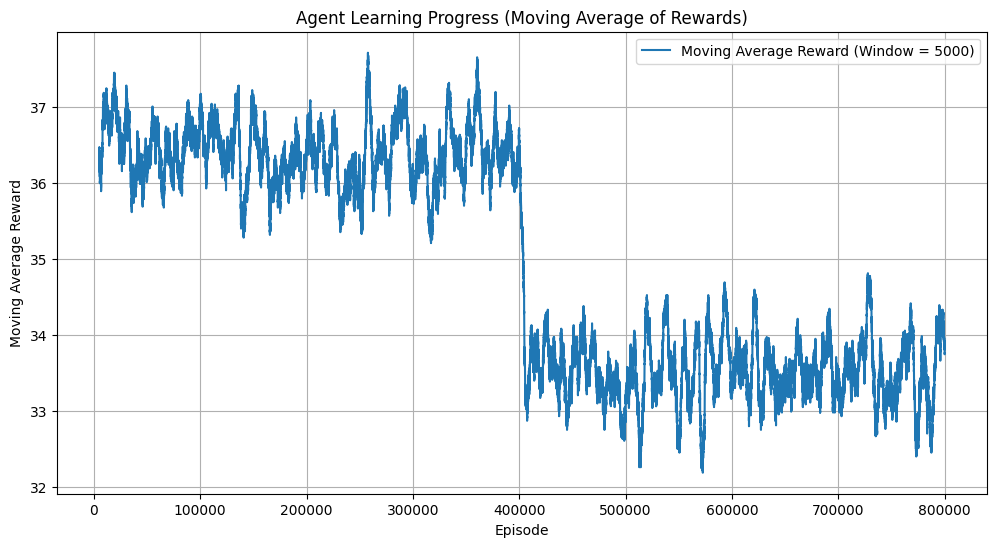

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a pandas Series from the episode_rewards list
rewards_series = pd.Series(episode_rewards)

# Calculate the moving average with a window size of 5000
window_size = 5000
moving_avg_rewards = rewards_series.rolling(window=window_size).mean()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(moving_avg_rewards, label=f'Moving Average Reward (Window = {window_size})')
plt.title('Agent Learning Progress (Moving Average of Rewards)')
plt.xlabel('Episode')
plt.ylabel('Moving Average Reward')
plt.legend()
plt.grid(True)
plt.show()